In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset



In [19]:
# 1) Load your dataset
df = pd.read_csv("delhi_air_anomaly_ready.csv", parse_dates=["date"])
df = df.sort_values("date").set_index("date")
df.index.name = "date"

print(df.columns)


Index(['year', 'month', 'season', 'pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3',
       'temperature_celsius', 'humidity', 'wind_kph', 'fire_count_all_india',
       'pm25_7day_avg', 'pm25_7day_std', 'pm25_deviation', 'aqi',
       'aqi_bucket'],
      dtype='object')


In [20]:
from sklearn.preprocessing import MinMaxScaler
# 2) Select features for LSTM autoencoder
feature_cols = [
    "pm2.5", "pm10", "no2", "so2", "co", "o3",
    "temperature_celsius", "humidity", "wind_kph",
    "fire_count_all_india",
    "pm25_deviation",
]

data = df[feature_cols].copy()
data = data.interpolate(limit_direction="both").fillna(0)

# MinMax scaling to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data.values.astype("float32"))

# Keep AQI for plotting
aqi_series = df["aqi"].copy()


In [21]:
window_size = 30  # number of days per window

def create_windows(values, window_size):
    X = []
    for i in range(len(values) - window_size + 1):
        X.append(values[i:i+window_size])
    return np.array(X)

# 3) Build windowed data
X_all = create_windows(data_scaled, window_size)   # shape: (N, T, F)

# Align AQI and dates to the end of each window
aqi_win = aqi_series[window_size-1:]
dates_win = aqi_win.index

print("X_all shape:", X_all.shape)


X_all shape: (3618, 30, 11)


In [22]:
# 4) Time split: first 70% windows for training, rest for validation
split_idx = int(len(X_all) * 0.7)
X_train = X_all[:split_idx]
X_val   = X_all[split_idx:]

print("Train:", X_train.shape, "Val:", X_val.shape)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)

train_ds = TensorDataset(X_train_t)
val_ds   = TensorDataset(X_val_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Train: (2532, 30, 11) Val: (1086, 30, 11)
Using device: cpu


In [23]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, latent_dim, seq_len):
        super().__init__()
        self.n_features = n_features
        self.latent_dim = latent_dim
        self.seq_len = seq_len

        self.encoder_lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=latent_dim,
            num_layers=1,
            batch_first=True
        )

        self.decoder_lstm = nn.LSTM(
            input_size=latent_dim,
            hidden_size=latent_dim,
            num_layers=1,
            batch_first=True
        )

        self.output_layer = nn.Linear(latent_dim, n_features)

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        _, (h_n, _) = self.encoder_lstm(x)    # h_n: (1, batch, latent_dim)
        h = h_n[-1]                           # (batch, latent_dim)

        # Repeat latent vector across seq_len
        h_repeated = h.unsqueeze(1).repeat(1, self.seq_len, 1)  # (batch, seq_len, latent_dim)

        decoded_seq, _ = self.decoder_lstm(h_repeated)          # (batch, seq_len, latent_dim)
        out = self.output_layer(decoded_seq)                    # (batch, seq_len, n_features)
        return out


In [24]:
seq_len = X_train.shape[1]
n_features = X_train.shape[2]
latent_dim = 64

model = LSTMAutoencoder(n_features, latent_dim, seq_len).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [25]:
n_epochs = 100
patience = 10
best_val_loss = np.inf
epochs_no_improve = 0
best_state = None

for epoch in range(1, n_epochs + 1):
    # ---- Train ----
    model.train()
    train_losses = []
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # ---- Validation ----
    model.eval()
    val_losses = []
    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)
            output = model(batch)
            loss = criterion(output, batch)
            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)

    print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    # Early stopping
    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = model.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping at epoch", epoch)
            break

# Load best weights
if best_state is not None:
    model.load_state_dict(best_state)


Epoch 001 | train_loss=0.108039 | val_loss=0.165333
Epoch 002 | train_loss=0.049805 | val_loss=0.168430
Epoch 003 | train_loss=0.048987 | val_loss=0.167986
Epoch 004 | train_loss=0.048859 | val_loss=0.170014
Epoch 005 | train_loss=0.048891 | val_loss=0.168798
Epoch 006 | train_loss=0.048842 | val_loss=0.168848
Epoch 007 | train_loss=0.048881 | val_loss=0.166846
Epoch 008 | train_loss=0.048870 | val_loss=0.165969
Epoch 009 | train_loss=0.048874 | val_loss=0.167147
Epoch 010 | train_loss=0.048838 | val_loss=0.165242
Epoch 011 | train_loss=0.048879 | val_loss=0.164445
Epoch 012 | train_loss=0.048847 | val_loss=0.163333
Epoch 013 | train_loss=0.048787 | val_loss=0.163935
Epoch 014 | train_loss=0.048615 | val_loss=0.162459
Epoch 015 | train_loss=0.048489 | val_loss=0.163169
Epoch 016 | train_loss=0.048447 | val_loss=0.163944
Epoch 017 | train_loss=0.048402 | val_loss=0.163111
Epoch 018 | train_loss=0.048293 | val_loss=0.162478
Epoch 019 | train_loss=0.048195 | val_loss=0.162828
Epoch 020 | 

In [26]:
# 7) Reconstruction on all windows
model.eval()
X_all_t = torch.tensor(X_all, dtype=torch.float32).to(device)

with torch.no_grad():
    X_all_pred_t = model(X_all_t)

X_all_pred = X_all_pred_t.cpu().numpy()

# Reconstruction error per window
recon_error = np.mean((X_all_pred - X_all) ** 2, axis=(1, 2))

# Build DataFrame aligned with window end dates
lstm_df = pd.DataFrame({
    "date": dates_win,
    "aqi": aqi_win.values,
    "lstm_score": recon_error
}).set_index("date")

# Threshold at 95th percentile (tune this)
threshold = np.quantile(lstm_df["lstm_score"], 0.95)
lstm_df["lstm_label"] = lstm_df["lstm_score"] > threshold

print("Threshold:", threshold)
print(lstm_df["lstm_label"].value_counts())


Threshold: 0.30822635889053346
lstm_label
False    3437
True      181
Name: count, dtype: int64


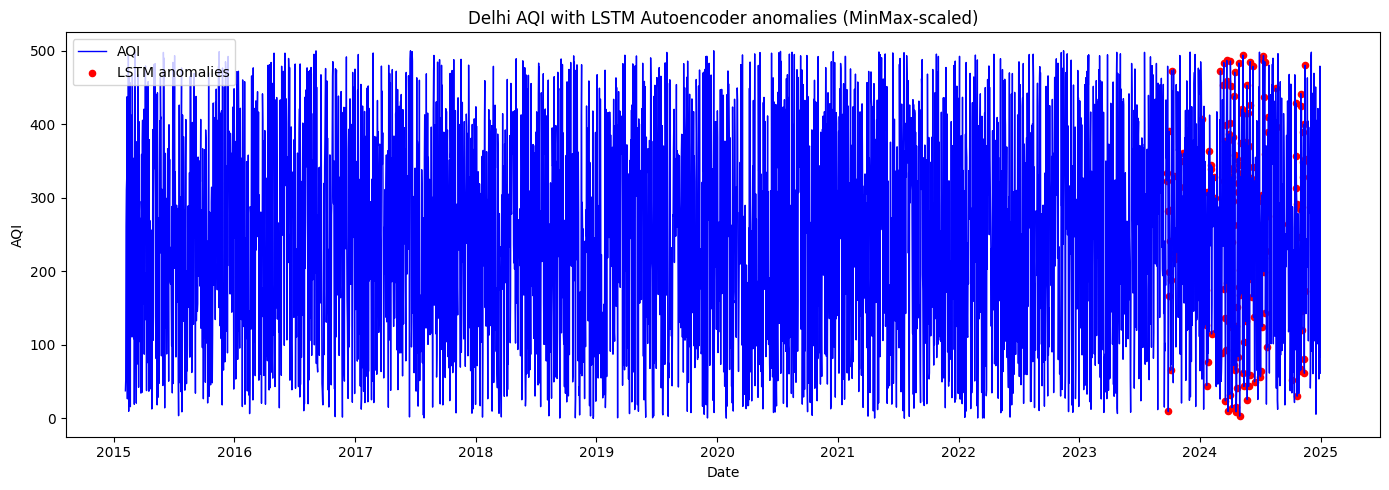

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(lstm_df.index, lstm_df["aqi"], label="AQI", color="blue", linewidth=1)

anoms = lstm_df[lstm_df["lstm_label"]]
plt.scatter(anoms.index, anoms["aqi"],
            color="red", s=20, label="LSTM anomalies")

plt.xlabel("Date")
plt.ylabel("AQI")
plt.title("Delhi AQI with LSTM Autoencoder anomalies (MinMax-scaled)")
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
df_lstm = df.copy()
df_lstm = df_lstm.join(lstm_df[["lstm_score", "lstm_label"]], how="left")

df_lstm.to_csv("delhi_air_anomaly_with_lstm_minmax_pytorch.csv")


In [29]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_size=64, latent_size=16, n_layers=1):
        super().__init__()
        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True
        )
        self.enc_fc = nn.Linear(hidden_size, latent_size)

        self.dec_fc = nn.Linear(latent_size, hidden_size)
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True
        )
        self.out = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        enc_out, (h, c) = self.encoder(x)          # enc_out: (B,T,H)
        latent = self.enc_fc(enc_out[:, -1, :])    # (B,latent)

        dec_init = self.dec_fc(latent)             # (B,H)
        dec_init = dec_init.unsqueeze(1).repeat(1, x.size(1), 1)  # (B,T,H)

        dec_out, _ = self.decoder(dec_init)
        out = self.out(dec_out)                    # (B,T,F)
        return out

n_features = X_train.shape[2]
model = LSTMAutoencoder(n_features=n_features, hidden_size=64, latent_size=16).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [30]:
n_epochs = 50

for epoch in range(1, n_epochs + 1):
    model.train()
    train_losses = []
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)
            recon = model(batch)
            loss = criterion(recon, batch)
            val_losses.append(loss.item())

    print(
        f"Epoch {epoch:03d} | "
        f"Train loss: {np.mean(train_losses):.6f} | "
        f"Val loss: {np.mean(val_losses):.6f}"
    )


Epoch 001 | Train loss: 0.095094 | Val loss: 0.167354
Epoch 002 | Train loss: 0.049699 | Val loss: 0.170248
Epoch 003 | Train loss: 0.048947 | Val loss: 0.170182
Epoch 004 | Train loss: 0.048889 | Val loss: 0.170249
Epoch 005 | Train loss: 0.048855 | Val loss: 0.172030
Epoch 006 | Train loss: 0.048876 | Val loss: 0.170698
Epoch 007 | Train loss: 0.048913 | Val loss: 0.171104
Epoch 008 | Train loss: 0.048885 | Val loss: 0.169986
Epoch 009 | Train loss: 0.048868 | Val loss: 0.169185
Epoch 010 | Train loss: 0.048837 | Val loss: 0.168216
Epoch 011 | Train loss: 0.048680 | Val loss: 0.169110
Epoch 012 | Train loss: 0.048646 | Val loss: 0.169410
Epoch 013 | Train loss: 0.048632 | Val loss: 0.169064
Epoch 014 | Train loss: 0.048596 | Val loss: 0.168816
Epoch 015 | Train loss: 0.048629 | Val loss: 0.169363
Epoch 016 | Train loss: 0.048607 | Val loss: 0.169875
Epoch 017 | Train loss: 0.048553 | Val loss: 0.170358
Epoch 018 | Train loss: 0.048560 | Val loss: 0.170630
Epoch 019 | Train loss: 0.04

In [31]:
model.eval()
with torch.no_grad():
    X_all_t = torch.tensor(X_all, dtype=torch.float32).to(device)
    recon_all = model(X_all_t).cpu().numpy()

recon_error = np.mean((X_all - recon_all) ** 2, axis=(1, 2))  # shape (N_windows,)

# Align with dates
error_series = pd.Series(recon_error, index=dates_win, name="recon_error")


In [33]:
# Example: threshold at mean + 3*std of training errors
train_err = error_series.iloc[:split_idx]
thr = train_err.mean() + 3 * train_err.std()
print("Threshold:", thr)

anomaly_flags = (error_series > thr).astype(int)
anomaly_series = anomaly_flags.rename("is_anomaly")


Threshold: 0.05775848007760942


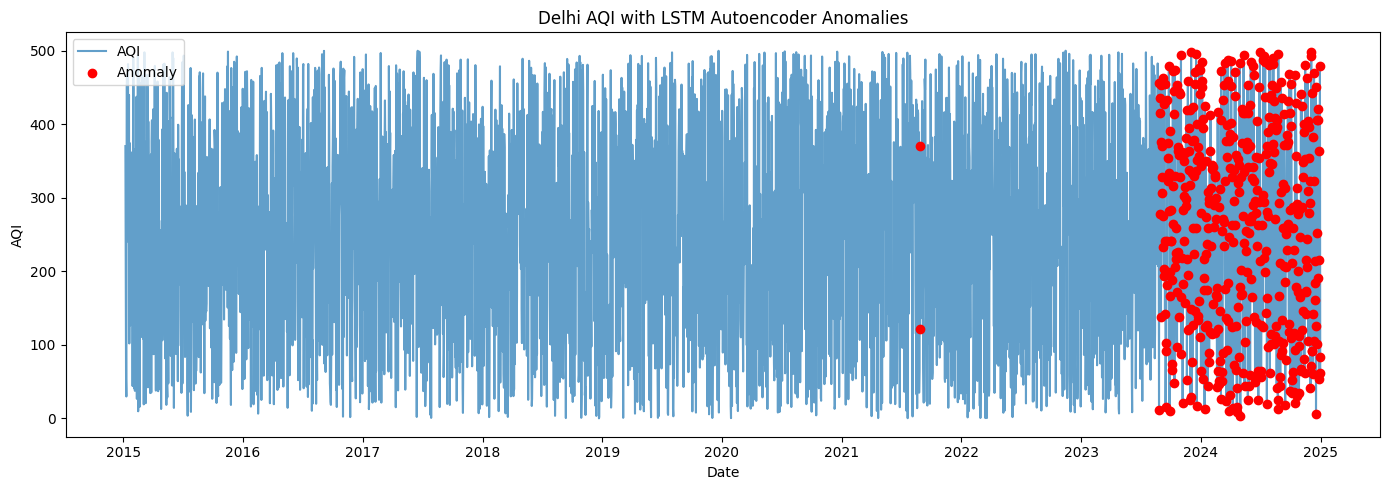

In [34]:
plt.figure(figsize=(14, 5))
plt.plot(aqi_series.index, aqi_series.values, label="AQI", alpha=0.7)

# Plot anomaly points (end of window dates)
anomaly_dates = anomaly_series[anomaly_series == 1].index
plt.scatter(
    anomaly_dates,
    aqi_series.loc[anomaly_dates],
    color="red",
    label="Anomaly",
    zorder=3
)

plt.title("Delhi AQI with LSTM Autoencoder Anomalies")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()
